# 7주차_데이터 전처리와 파생변수 생성 Ⅱ

- 모델 성능 향상을 위한 파생 변수 생성

---

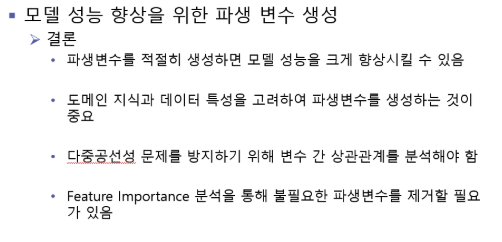

In [26]:
# 필요한 패키지 설치

import math
# 수학 관련 함수(루트, 로그, 삼각함수 등)를 제공하는 내장 math 모듈을 임포트함

from sklearn import preprocessing
# 데이터 전처리 함수들(스케일링, 인코딩 등)을 포함한 sklearn.preprocessing 모듈을 임포트함
# 예: LabelEncoder, StandardScaler, MinMaxScaler 등

import datetime
# 날짜 및 시간 데이터를 다루기 위한 기본 datetime 모듈을 임포트함

from datetime import timedelta
# datetime 모듈에서 timedelta 클래스를 개별로 임포트함
# 날짜 간 차이나 일정 시간 간격을 계산할 때 사용함

import numpy as np
# 수치 계산, 배열 연산 등을 위한 핵심 수학 라이브러리 numpy를 임포트함

import matplotlib.pyplot as plt
# 데이터 시각화를 위한 matplotlib의 핵심 서브모듈 pyplot을 임포트함

plt.rcParams['figure.dpi'] = 300
# 시각화 결과물의 출력 해상도를 300 DPI로 설정함
# 고화질 이미지 출력이 필요한 분석 리포트나 논문용 시각화에 유용함


In [27]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/marian447/retail-store-sales-transactions
df = pd.read_csv("../../main/datasets/scanner_data.csv")

# 데이터 샘플 확인
df.head()

,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount
0,1,02/01/2016,2547,1,X52,0EM7L,1.0,3.13
1,2,02/01/2016,822,2,2ML,68BRQ,1.0,5.46
2,3,02/01/2016,3686,3,0H2,CZUZX,1.0,6.35
3,4,02/01/2016,3719,4,0H2,549KK,1.0,5.59
4,5,02/01/2016,9200,5,0H2,K8EHH,1.0,6.88


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131706 entries, 0 to 131705
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      131706 non-null  int64  
 1   Date            131706 non-null  object 
 2   Customer_ID     131706 non-null  int64  
 3   Transaction_ID  131706 non-null  int64  
 4   SKU_Category    131706 non-null  object 
 5   SKU             131706 non-null  object 
 6   Quantity        131706 non-null  float64
 7   Sales_Amount    131706 non-null  float64
dtypes: float64(2), int64(3), object(3)
memory usage: 8.0+ MB


| 컬럼명 | 데이터 예시 | 의미 해석 |
| --- | --- | --- |
| `Unnamed: 0` | 1, 2, 3, ... | **행 번호 또는 인덱스**를 나타냄 (CSV 저장 시 자동 생성된 인덱스 열일 가능성이 높음, 분석에 불필요하면 삭제 가능) |
| `Date` | `02/01/2016` | 거래가 발생한 **날짜** (거래 일자, 형식: 일/월/연도) |
| `Customer_ID` | `2547`, `822` | **고객 고유 ID**를 나타냄 (한 고객이 여러 번 등장할 수 있음) |
| `Transaction_ID` | `1`, `2`, `3` | **거래 건별 고유 식별자** (단일 거래 번호, 하나의 구매 행위 단위) |
| `SKU_Category` | `X52`, `2ML` | 상품의 **카테고리 코드** (예: 상품 대분류 또는 그룹 코드) |
| `SKU` | `0EM7L`, `68BRQ` | **개별 상품 코드** (Stock Keeping Unit, SKU; 고유 제품 단위) |
| `Quantity` | `1.0`, `2.0` | 해당 SKU의 **구매 수량** (주로 정수지만 소수점도 가능) |
| `Sales_Amount` | `3.13`, `5.46` | 해당 거래에서의 **매출 금액 (수량 × 단가)** |

In [29]:
df.shape

(131706, 8)

In [30]:
df.describe()

,Unnamed: 0,Customer_ID,Transaction_ID,Quantity,Sales_Amount
count,131706.000000,131706.000000,131706.000000,131706.000000,131706.000000
mean,65853.500000,12386.450367,32389.604187,1.485311,11.981524
std,38020.391614,6086.447552,18709.901238,3.872667,19.359699
min,1.000000,1.000000,1.000000,0.010000,0.020000
25%,32927.250000,7349.000000,16134.000000,1.000000,4.230000
50%,65853.500000,13496.000000,32620.000000,1.000000,6.920000
75%,98779.750000,17306.000000,48548.000000,1.000000,12.330000
max,131706.000000,22625.000000,64682.000000,400.000000,707.730000


In [31]:
df.select_dtypes(include="number").skew()

Unnamed: 0         0.000000
Customer_ID       -0.411699
Transaction_ID    -0.014006
Quantity          31.804042
Sales_Amount       7.434629
dtype: float64

In [32]:
df.select_dtypes(include='number').kurtosis()

Unnamed: 0          -1.200000
Customer_ID         -1.016342
Transaction_ID      -1.201488
Quantity          1705.129556
Sales_Amount        89.244068
dtype: float64

In [33]:
df.isnull().sum()

Unnamed: 0        0
Date              0
Customer_ID       0
Transaction_ID    0
SKU_Category      0
SKU               0
Quantity          0
Sales_Amount      0
dtype: int64

In [34]:
# 두 개의 변수 결합한 파생변수 생성

# 구매 상품당 가격 컬럼 생성
df['Unit_amount'] = df['Sales_Amount']/df['Quantity']

# 총 구매가격 컬럼 생성
# df['All_amount'] = \
# df[['Quantity', 'Sales_Amount']].apply(lambda series: series.prod(), axis=1)
df['All_amount'] = df['Quantity'] * df['Sales_Amount']

df.tail()

,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Unit_amount,All_amount
131701,131702,04/07/2016,20203,32900,IEV,FO112,3.0,6.46,2.153333,19.38
131702,131703,04/07/2016,20203,32900,N8U,I36F2,1.0,4.50,4.500000,4.50
131703,131704,04/07/2016,20203,32900,U5F,4X8P4,1.0,5.19,5.190000,5.19
131704,131705,04/07/2016,20203,32900,0H2,ZVTO4,1.0,4.57,4.570000,4.57
131705,131706,04/07/2016,20203,32900,Q4N,QM9BP,1.0,13.68,13.680000,13.68


In [35]:
# 로그, 제곱근, 제곱 변환 파생변수 생성

# 방법1. Sales_Amount 컬럼에 로그 변환 + 표준화 적용
df['Sales_Amount_log'] = preprocessing.scale(np.log(df['Sales_Amount'] + 1))
# np.log(): 로그 함수로, 수치가 클수록 성장 폭이 줄어드는 비선형 변환을 수행함
# 로그 변환은 특히 양의 왜도(오른쪽 꼬리 분포)를 줄이고 정규성(normality)을 높이는 데 효과적임
# +1은 log(0) 오류를 방지하기 위한 보정값이며, 값이 0인 경우에도 변환 가능하도록 처리함
# preprocessing.scale(): 변환된 값을 평균 0, 표준편차 1로 표준화하여 스케일을 통일함
# → 목적: 왜도 완화 + 정규분포에 가까운 스케일 통일

# 방법2. Sales_Amount 컬럼에 로그만 적용 (표준화 X)
df['Sales_Amount_log2'] = df[['Sales_Amount']].apply(lambda x: np.log(x + 1))
# 같은 로그 변환이지만, 여기서는 표준화 없이 로그값 자체만 계산함
# 머신러닝 모델이 스케일을 자동으로 보정할 수 있거나, 단순히 분포 시각화용으로 사용할 때 적합함
# apply(lambda x: ...)를 사용하여 열 단위로 수학 함수를 적용함
# → 목적: 분포 비대칭성 완화만 적용, 스케일 유지

# 제곱근 변환: Sales_Amount 컬럼에 제곱근 변환 적용
df['Sales_Amount_sqrt'] = np.sqrt(df['Sales_Amount'] + 1)
# np.sqrt(): 제곱근 함수로, 로그보다 완만하게 값을 눌러주는 방식임
# 큰 값을 작게 줄이면서 분포의 왜도를 완화하지만, 로그보다는 정규성 효과가 약함
# 역시 +1 보정으로 0 이하 오류 방지
# → 목적: 완만한 스케일 감소 + 왜도 보정 (로그보다 덜 민감함)

# 제곱 변환: Sales_Amount 컬럼에 제곱 적용
df['Sales_Amount_pow'] = pow(df[['Sales_Amount']], 2)
# pow(): 각 값을 제곱하여 수치의 범위를 확장함
# 음의 왜도를 가지는 분포(왼쪽 꼬리)를 대칭적으로 보정하거나, 고스케일 변수 강조 시 사용됨
# → 목적: 음의 왜도 보정 또는 큰 값을 더 크게 확대하여 모델 가중치를 민감하게 만들기 위함

# 결과 확인
df.tail()
# 생성된 파생 컬럼이 원본 'Sales_Amount'과 어떻게 달라졌는지 확인함
# 변환 전후 값을 비교하여 정규성 변화 또는 이상치 영향 완화 여부를 판단 가능함


,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Unit_amount,All_amount,Sales_Amount_log,Sales_Amount_log2,Sales_Amount_sqrt,Sales_Amount_pow
131701,131702,04/07/2016,20203,32900,IEV,FO112,3.0,6.46,2.153333,19.38,-0.204581,2.009555,2.731300,41.7316
131702,131703,04/07/2016,20203,32900,N8U,I36F2,1.0,4.50,4.500000,4.50,-0.592329,1.704748,2.345208,20.2500
131703,131704,04/07/2016,20203,32900,U5F,4X8P4,1.0,5.19,5.190000,5.19,-0.441982,1.822935,2.487971,26.9361
131704,131705,04/07/2016,20203,32900,0H2,ZVTO4,1.0,4.57,4.570000,4.57,-0.576240,1.717395,2.360085,20.8849
131705,131706,04/07/2016,20203,32900,Q4N,QM9BP,1.0,13.68,13.680000,13.68,0.656548,2.686486,3.831449,187.1424


In [36]:
# 월 합계, 평균 구매금액 변수 생성

# date 컬럼 날짜형식 변환
df['Date2'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='raise')
# 'Date' 문자열 컬럼을 datetime 형식으로 변환하여 'Date2'라는 새 컬럼에 저장함
# format='%d/%m/%Y'로 일/월/연도 형식을 명시함 (예: 15/06/2021)
# errors='raise'는 변환 실패 시 오류를 발생시키는 설정으로, 형식 오류 데이터 확인에 유용함

# 연도 컬럼 생성
df['Year'] = df['Date2'].dt.year
# 'Date2'에서 연도 정보만 추출하여 'Year' 컬럼으로 생성함
# 이후 연도 단위 분석이나 시계열 집계를 위한 전처리 작업임

# 월 컬럼 생성
df['Month'] = df['Date2'].dt.month
# 'Date2'에서 월 정보만 추출하여 'Month' 컬럼으로 생성함
# 월 단위 집계 및 시각화를 위한 전처리 작업임

# 연월-고객별 매출 합계, 평균 컬럼 생성
df_sm = df.groupby(['Year', 'Month', 'Customer_ID'])['Sales_Amount'].agg(['sum', 'mean']).reset_index()
# 'Year', 'Month', 'Customer_ID'를 기준으로 그룹화하여 'Sales_Amount'의 합계(sum)와 평균(mean)을 계산함
# reset_index()를 통해 결과를 일반적인 데이터프레임 형태로 변환함
# 고객별 월간 총매출과 평균 매출을 나타내는 파생 테이블 생성 단계임

# 기존 일별 테이블에 평균 테이블 조인
df2 = pd.merge(df, df_sm, how='left')
# 원래 df와 집계 결과 df_sm을 'Year', 'Month', 'Customer_ID'를 키로 하여 left join 방식으로 병합함
# 기존의 일별 거래 테이블에 월간 합계 및 평균 정보를 함께 붙여 통합 정보 구성함

df2.head()
# 병합된 df2의 상위 5개 행을 출력하여 집계 결과가 정확히 결합되었는지 확인함
# 일별 데이터와 월 집계 정보가 같은 행에 잘 연결되었는지 시각적으로 검증하는 과정임


,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Unit_amount,All_amount,Sales_Amount_log,Sales_Amount_log2,Sales_Amount_sqrt,Sales_Amount_pow,Date2,Year,Month,sum,mean
0,1,02/01/2016,2547,1,X52,0EM7L,1.0,3.13,3.13,3.13,-0.956750,1.418277,2.032240,9.7969,2016-01-02,2016,1,27.01,6.752500
1,2,02/01/2016,822,2,2ML,68BRQ,1.0,5.46,5.46,5.46,-0.387670,1.865629,2.541653,29.8116,2016-01-02,2016,1,14.05,3.512500
2,3,02/01/2016,3686,3,0H2,CZUZX,1.0,6.35,6.35,6.35,-0.223478,1.994700,2.711088,40.3225,2016-01-02,2016,1,135.16,7.113684
3,4,02/01/2016,3719,4,0H2,549KK,1.0,5.59,5.59,5.59,-0.362325,1.885553,2.567100,31.2481,2016-01-02,2016,1,244.83,9.793200
4,5,02/01/2016,9200,5,0H2,K8EHH,1.0,6.88,6.88,6.88,-0.134904,2.064328,2.807134,47.3344,2016-01-02,2016,1,6.88,6.880000


In [37]:
# 월 평균 구매금액 대비 일 별 구매금액 차이 변수 생성
df2['Sales_Amount_Diff'] = df2['mean'] - df2['Sales_Amount']
# 고객의 해당 월 평균 구매금액(mean)에서 개별 일별 구매금액(Sales_Amount)을 뺀 값을 계산함
# 값이 양수면 평균보다 적게 구매한 날, 음수면 평균보다 많이 구매한 날을 의미함
# 고객의 일별 소비 편차를 정량적으로 분석하기 위한 파생 변수임

# 월 평균 구매금액 대비 일 별 구매금액 비율 변수 생성
df2['Sales_Amount_UD'] = df2['Sales_Amount'] / df2['mean']
# 일별 구매금액을 월 평균 구매금액으로 나눈 비율을 계산함
# 평균 구매 수준을 1로 놓고, 일별 소비가 평균보다 높은지(>1), 낮은지(<1)를 파악할 수 있음
# 일별 구매 강도 또는 비율 기반 스케일 정규화된 변수로 활용 가능함

# 월 총 구매금액 대비 일 별 구매금액 비율 변수 생성
df2['Sales_Amount_Rto'] = df2['Sales_Amount'] / df2['sum']
# 해당 고객의 월 전체 구매금액 대비 일별 구매금액의 비율을 계산함
# 0~1 사이의 값으로 표현되며, 해당 일의 구매가 한 달 중 얼마나 큰 비중을 차지하는지를 나타냄
# 고객별 중요일 탐지, 월간 집중 소비일 분석 등에 활용 가능함

df2.head()
# 파생 변수가 정상적으로 생성되었는지 확인하기 위해 상위 5개 행을 출력함
# 각 비율 및 차이 값이 직관적으로 이해되는 범위 내에 있는지 시각적으로 검토하는 단계임


,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Unit_amount,All_amount,...,Sales_Amount_sqrt,Sales_Amount_pow,Date2,Year,Month,sum,mean,Sales_Amount_Diff,Sales_Amount_UD,Sales_Amount_Rto
0,1,02/01/2016,2547,1,X52,0EM7L,1.0,3.13,3.13,3.13,...,2.032240,9.7969,2016-01-02,2016,1,27.01,6.752500,3.622500,0.463532,0.115883
1,2,02/01/2016,822,2,2ML,68BRQ,1.0,5.46,5.46,5.46,...,2.541653,29.8116,2016-01-02,2016,1,14.05,3.512500,-1.947500,1.554448,0.388612
2,3,02/01/2016,3686,3,0H2,CZUZX,1.0,6.35,6.35,6.35,...,2.711088,40.3225,2016-01-02,2016,1,135.16,7.113684,0.763684,0.892646,0.046981
3,4,02/01/2016,3719,4,0H2,549KK,1.0,5.59,5.59,5.59,...,2.567100,31.2481,2016-01-02,2016,1,244.83,9.793200,4.203200,0.570804,0.022832
4,5,02/01/2016,9200,5,0H2,K8EHH,1.0,6.88,6.88,6.88,...,2.807134,47.3344,2016-01-02,2016,1,6.88,6.880000,0.000000,1.000000,1.000000


In [38]:
# 전월 비교용 파생변수 생성 (※ 4주 뒤 월의 기준으로 현재 매출을 과거 매출로 간주함)

# 4주 뒤 시점 컬럼 생성
df2['Date2_1_m'] = df2['Date2'] + timedelta(weeks=4)
# 'Date2' 기준으로 4주(약 1개월)를 더한 날짜를 계산하여 'Date2_1_m' 컬럼 생성
# 미래 날짜를 기준으로 현재 데이터를 과거로 보고 전월 매출처럼 참조하기 위한 구조임

# 4주 뒤 시점의 연도 컬럼 생성
df['Year_1_m'] = df2['Date2_1_m'].dt.year
# 'Date2_1_m'에서 연도(year)만 추출하여 'Year_1_m' 컬럼 생성
# 이후 미래 월 정보를 기준으로 그룹핑하기 위한 키로 사용됨

# 4주 뒤 시점의 월 컬럼 생성
df['Month_1_m'] = df2['Date2_1_m'].dt.month
# 'Date2_1_m'에서 월(month)만 추출하여 'Month_1_m' 컬럼 생성
# 이후 미래 월 정보를 기준으로 그룹핑하기 위한 키로 사용됨

# 4주 뒤의 연월 기준으로 고객별 월간 매출 합계 및 평균 계산
df_Mn_1 = df.groupby(['Year_1_m', 'Month_1_m', 'Customer_ID']
                     )['Sales_Amount'].agg(['sum', 'mean']).reset_index()
# 미래(4주 뒤)의 연월 기준으로 고객별 월 총 매출(sum)과 평균 매출(mean)을 계산함
# 현재 시점의 데이터를 4주 뒤 기준으로 병합하기 위해 미래 키를 사용한 집계 테이블 생성

# 조인을 위한 컬럼명 변경
df_Mn_1.rename(columns={
    'Year_1_m': 'Year',
    'Month_1_m': 'Month',
    'sum': 'sum_1_m',
    'mean': 'mean_1_m'
}, inplace=True)
# 병합을 위해 미래 연월 컬럼명을 'Year', 'Month'로 바꾸고,
# 집계된 매출 컬럼명을 'sum_1_m', 'mean_1_m'으로 명확히 지정함 (4주 뒤 기준 매출)

# df2에 미래 기준 매출 데이터를 병합
df2 = pd.merge(df2, df_Mn_1, how='left')
# df2의 (Year, Month, Customer_ID) 기준으로 df_Mn_1과 left join 수행
# 결과적으로, 현재 데이터에 대해 4주 뒤의 월 기준에서 본 고객의 매출 정보를 병합함
# 즉, 4주 뒤 기준으로 현재 시점을 '전월'처럼 간주하여 참조하는 방식

df2.head()
# 병합된 결과를 확인하여, 미래 기준 매출 정보가 잘 붙었는지 확인함


,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Unit_amount,All_amount,...,Year,Month,sum,mean,Sales_Amount_Diff,Sales_Amount_UD,Sales_Amount_Rto,Date2_1_m,sum_1_m,mean_1_m
0,1,02/01/2016,2547,1,X52,0EM7L,1.0,3.13,3.13,3.13,...,2016,1,27.01,6.752500,3.622500,0.463532,0.115883,2016-01-30,3.13,3.13
1,2,02/01/2016,822,2,2ML,68BRQ,1.0,5.46,5.46,5.46,...,2016,1,14.05,3.512500,-1.947500,1.554448,0.388612,2016-01-30,5.46,5.46
2,3,02/01/2016,3686,3,0H2,CZUZX,1.0,6.35,6.35,6.35,...,2016,1,135.16,7.113684,0.763684,0.892646,0.046981,2016-01-30,6.35,6.35
3,4,02/01/2016,3719,4,0H2,549KK,1.0,5.59,5.59,5.59,...,2016,1,244.83,9.793200,4.203200,0.570804,0.022832,2016-01-30,5.59,5.59
4,5,02/01/2016,9200,5,0H2,K8EHH,1.0,6.88,6.88,6.88,...,2016,1,6.88,6.880000,0.000000,1.000000,1.000000,2016-01-30,6.88,6.88


In [39]:
# 전 월과의 차이 파생변수 생성

# 전 월 대비 구매금액 평균 차이 변수 생성
df2['Mn_diff_1_mean'] = df2['mean'] - df2['mean_1_m']
# 현재 연/월의 고객 평균 구매금액(mean)에서 4주 뒤 연/월 기준으로 병합한 이전 월 평균 구매금액(mean_1_m)을 뺀 차이를 계산함
# 구조상 mean_1_m은 현재 기준에서 1개월 전 고객의 월 평균 매출로 간주됨
# 값이 양수면 전월보다 평균 구매금액이 증가한 것, 음수면 감소한 것을 의미함

# 전 월 대비 총 구매금액 차이 변수 생성
df2['Mn_diff_1_sum'] = df2['sum'] - df2['sum_1_m']
# 현재 연/월의 고객 총 구매금액(sum)에서 4주 뒤 기준으로 병합된 전월 총 구매금액(sum_1_m)을 뺀 차이를 계산함
# 양수: 전월 대비 매출 증가, 음수: 매출 감소

df2.head()
# 계산된 차이 파생변수가 정상적으로 생성되었는지 상위 5개 행을 출력하여 확인함


,Unnamed: 0,Date,Customer_ID,Transaction_ID,SKU_Category,SKU,Quantity,Sales_Amount,Unit_amount,All_amount,...,sum,mean,Sales_Amount_Diff,Sales_Amount_UD,Sales_Amount_Rto,Date2_1_m,sum_1_m,mean_1_m,Mn_diff_1_mean,Mn_diff_1_sum
0,1,02/01/2016,2547,1,X52,0EM7L,1.0,3.13,3.13,3.13,...,27.01,6.752500,3.622500,0.463532,0.115883,2016-01-30,3.13,3.13,3.622500,23.88
1,2,02/01/2016,822,2,2ML,68BRQ,1.0,5.46,5.46,5.46,...,14.05,3.512500,-1.947500,1.554448,0.388612,2016-01-30,5.46,5.46,-1.947500,8.59
2,3,02/01/2016,3686,3,0H2,CZUZX,1.0,6.35,6.35,6.35,...,135.16,7.113684,0.763684,0.892646,0.046981,2016-01-30,6.35,6.35,0.763684,128.81
3,4,02/01/2016,3719,4,0H2,549KK,1.0,5.59,5.59,5.59,...,244.83,9.793200,4.203200,0.570804,0.022832,2016-01-30,5.59,5.59,4.203200,239.24
4,5,02/01/2016,9200,5,0H2,K8EHH,1.0,6.88,6.88,6.88,...,6.88,6.880000,0.000000,1.000000,1.000000,2016-01-30,6.88,6.88,0.000000,0.00
